In [1]:
import os
os.chdir('..')

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from src.data_io import *
from src.models import *
from src.volatility_estimates import *
from util.features import *
from util.notebook_plots import *

# Download Data

In [4]:
symbol = 'SPY'
start_date = '2000-01-03'
end_date = '2021-12-28'

params = {
    'symbol': symbol,
    'start_date': start_date,
    'end_date': end_date,
    'interval': '1d'
}
yf = YahooFinance(**params)
df = yf.pipeline()
df.head(5)

[*********************100%***********************]  1 of 1 completed


Price,date,Adj Close,Close,High,Low,Open,Volume,log_return
0,2000-01-03,91.617081,145.4375,148.25000,143.875000,148.25000,8164300,NaN
1,2000-01-04,88.034264,139.7500,144.06250,139.640625,143.53125,8089800,-0.039892
2,2000-01-05,88.191742,140.0000,141.53125,137.250000,139.93750,12177900,0.001787
3,2000-01-06,86.774368,137.7500,141.50000,137.750000,139.62500,6227200,-0.016202
4,2000-01-07,91.813911,145.7500,145.75000,140.062500,140.31250,8066500,0.056453


In [5]:
df['garman_klass'] = VolatilityMeasures(df).garman_klass_volatility(df['Close'], df['High'], df['Low'], df['Open'])
df.head(5)

Price,date,Adj Close,Close,High,Low,Open,Volume,log_return,garman_klass
0,2000-01-03,91.617081,145.4375,148.25000,143.875000,148.25000,8164300,NaN,0.017520
1,2000-01-04,88.034264,139.7500,144.06250,139.640625,143.53125,8089800,-0.039892,0.014512
2,2000-01-05,88.191742,140.0000,141.53125,137.250000,139.93750,12177900,0.001787,0.021718
3,2000-01-06,86.774368,137.7500,141.50000,137.750000,139.62500,6227200,-0.016202,0.017032
4,2000-01-07,91.813911,145.7500,145.75000,140.062500,140.31250,8066500,0.056453,0.015289


In [7]:
train_end_date = pd.Timestamp('2019-11-17')
train_df = df.loc[df['date'] < train_end_date, ['garman_klass', 'date']]
train_df.set_index('date', drop=True, inplace=True)
train_df.tail(5)

Price,garman_klass
date,
2019-11-11,0.002232
2019-11-12,0.004179
2019-11-13,0.003579
2019-11-14,0.003203
2019-11-15,0.003246


# Modified HAR-X Model

In this section, we will constrain ourselves to data found on Yahoo Finance. This reduces the number of source dependency and timing mismatch between candlestick time and source publication time.

In [8]:
exo_symbols = ['^VIX', '^VVIX', '^MOVE', '^GVZ', '^OVX']
exo_df = []
for s in exo_symbols:
    params = {
        'symbol': s,
        'start_date': start_date,
        'end_date': end_date,
        'interval': '1d'
    }
    tmp = YahooFinance(**params)
    tmp_df = tmp.pipeline()
    tmp = format_yf_df(tmp_df)
    tmp.columns = [s]
    exo_df.append(tmp)

exo_df = pd.concat(exo_df, axis=1)
exo_df.index = pd.to_datetime(exo_df.index, format='%d/%m/%Y')
exo_df = exo_df.sort_index(ascending=True)
exo_df.head(5)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,^VIX,^VVIX,^MOVE,^GVZ,^OVX
date,,,,,
2000-01-03,24.209999,NaN,NaN,NaN,NaN
2000-01-04,27.010000,NaN,NaN,NaN,NaN
2000-01-05,26.410000,NaN,NaN,NaN,NaN
2000-01-06,25.730000,NaN,NaN,NaN,NaN
2000-01-07,21.719999,NaN,NaN,NaN,NaN


Note that we only have all available data around 2008, so the comparison might not be fair for earlier periods. However, we are more interested in the forecasting capabilities in the current market environment.

In [10]:
exo_df.dropna().head(5)

,^VIX,^VVIX,^MOVE,^GVZ,^OVX
date,,,,,
2008-06-03,20.240000,79.720001,132.699997,22.889999,41.750000
2008-06-04,20.799999,81.040001,131.899994,22.690001,40.770000
2008-06-05,18.629999,79.349998,133.800003,22.780001,41.369999
2008-06-06,23.559999,88.779999,139.600006,23.600000,52.029999
2008-06-09,23.120001,92.230003,151.000000,24.469999,45.570000


In [19]:
harx = DirectHARX(train_df, exo_df)
harx.fit(horizon=5)
harx.fitted_values.head(5)

,prev_day,weekly_rolling_avg,monthly_rolling_avg,^VIX,^VVIX,^MOVE,^GVZ,^OVX,target
date,,,,,,,,,
2015-10-06,0.005865,0.009570,0.009146,19.40,92.459999,80.300003,17.540001,44.139999,0.006091
2015-10-07,0.006881,0.008838,0.008964,18.40,89.430000,80.000000,17.129999,43.259998,0.006178
2015-10-08,0.008212,0.008908,0.008964,17.42,88.419998,79.500000,16.910000,43.279999,0.005783
2015-10-09,0.007756,0.008485,0.008980,17.08,89.080002,78.199997,16.920000,42.799999,0.005534
2015-10-13,0.002969,0.006091,0.008349,17.67,98.349998,76.300003,17.139999,45.369999,0.005612


In [12]:
harx.forecast()

np.float64(0.004055515999330198)

Currently, we can see that the coefficients for the exogenous variables are small relative to the coefficients of the volatility-derived features. Perhaps, it would be better to set them on the same scale by taking the log returns. This would allow us to properly intepret the impact of each variable.

In [20]:
harx_backtest = harx.backtest(horizon=5)
print(f"MSE: {harx.mse}")
harx_backtest.head(5)

MSE: 3.3172468645442826e-06


,beta_prev_day,beta_weekly_rolling_avg,beta_monthly_rolling_avg,beta_^VIX,beta_^VVIX,beta_^MOVE,beta_^GVZ,beta_^OVX,intercept,y_hat,target
date,,,,,,,,,,,
2012-05-31,0.021902,0.198668,-0.228521,0.000434,0.000037,0.000033,0.000277,-0.000096,-0.010078,0.010323,0.009800
2012-06-01,0.021828,0.198721,-0.228280,0.000435,0.000037,0.000033,0.000276,-0.000096,-0.010066,0.011580,0.008849
2012-06-04,0.021729,0.198867,-0.227330,0.000435,0.000037,0.000033,0.000276,-0.000097,-0.010025,0.012097,0.006890
2012-06-05,0.020631,0.199018,-0.226225,0.000436,0.000036,0.000033,0.000275,-0.000097,-0.009977,0.010949,0.006970
2012-06-06,0.021267,0.197527,-0.225132,0.000437,0.000036,0.000033,0.000275,-0.000098,-0.009949,0.009206,0.007521


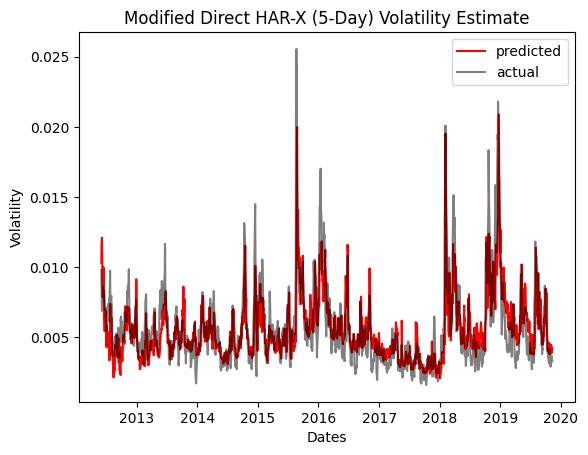

In [21]:
fig = plot_volatility_estimate(harx.eval['y_hat'], harx.eval['target'], 'Modified Direct HAR-X (5-Day) Volatility Estimate')
plt.show()

## Feature Scaling

In [22]:
scaled_exo_df = np.log(exo_df/ exo_df.shift(1))
scaled_exo_df.tail(5)

,^VIX,^VVIX,^MOVE,^GVZ,^OVX
date,,,,,
2021-12-20,0.058523,0.019001,0.061030,0.045403,0.220698
2021-12-21,-0.084828,-0.053775,0.031943,-0.022444,-0.141149
2021-12-22,-0.120225,-0.068580,-0.034153,-0.031623,-0.128546
2021-12-23,-0.036626,-0.018425,0.005709,-0.021652,-0.051065
2021-12-27,-0.015713,-0.038417,0.035961,0.054571,-0.002979


In [23]:
scaled_harx = DirectHARX(train_df, scaled_exo_df)
scaled_harx.fit(horizon=5)
scaled_harx.fitted_values.head(5)

,prev_day,weekly_rolling_avg,monthly_rolling_avg,^VIX,^VVIX,^MOVE,^GVZ,^OVX,target
date,,,,,,,,,
2015-08-24,0.019087,0.009994,0.006511,0.373935,0.197043,0.065597,0.140138,0.115142,0.023006
2015-08-25,0.055777,0.019945,0.008820,-0.123136,-0.101778,-0.036642,-0.051145,-0.022400,0.013339
2015-08-26,0.017116,0.022729,0.009306,-0.172267,-0.126489,0.009831,-0.008451,-0.044443,0.012749
2015-08-27,0.022428,0.025472,0.010126,-0.149872,-0.043522,-0.006543,-0.066571,0.045055,0.010423
2015-08-28,0.013335,0.025549,0.010371,-0.001918,-0.011026,-0.003288,0.003197,0.050314,0.009933


In [24]:
scaled_harx_backtest = scaled_harx.backtest(horizon=5)
print(f"MSE: {scaled_harx.mse}")
scaled_harx_backtest.head(5)

MSE: 4.066532361051766e-06


,beta_prev_day,beta_weekly_rolling_avg,beta_monthly_rolling_avg,beta_^VIX,beta_^VVIX,beta_^MOVE,beta_^GVZ,beta_^OVX,intercept,y_hat,target
date,,,,,,,,,,,
2012-06-12,0.111032,0.474601,0.311517,0.014538,-0.004011,0.015724,0.003684,0.003993,0.001174,0.007597,0.007680
2012-06-13,0.110965,0.474612,0.311608,0.014530,-0.004014,0.015730,0.003689,0.004001,0.001173,0.009832,0.007888
2012-06-14,0.110878,0.474896,0.311622,0.014620,-0.004133,0.015700,0.003654,0.003986,0.001167,0.007366,0.007985
2012-06-15,0.110905,0.474866,0.311427,0.014667,-0.004106,0.015742,0.003604,0.004173,0.001173,0.009206,0.008222
2012-06-18,0.110873,0.474906,0.311467,0.014684,-0.004131,0.015703,0.003615,0.004178,0.001171,0.004436,0.008334


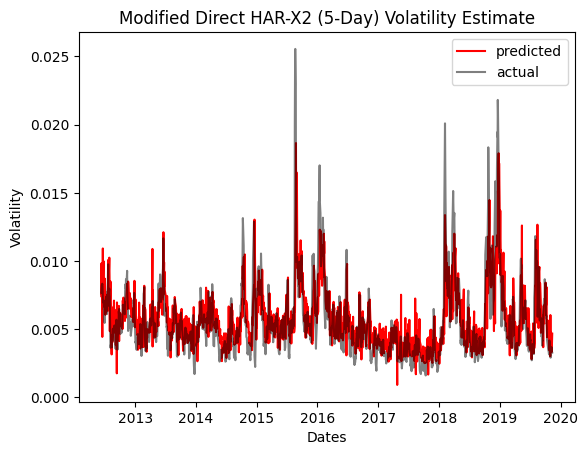

In [25]:
fig = plot_volatility_estimate(scaled_harx.eval['y_hat'], scaled_harx.eval['target'], 'Modified Direct HAR-X2 (5-Day) Volatility Estimate')
plt.show()

# Data Exploration

## Coefficients Analysis

Based on the coefficients, we note the increasing importance of the previous day volatility and the consistent importance of the weekly and monthly volatility. However, our exogenous variables have little to no impact on the volatility. Perhaps we should look at those variables by themselves.

In [40]:
def plot_coeffs(coeffs:pd.DataFrame, title:str) -> plt.Figure:
    plt.figure(figsize=(20,10))
    plt.plot(coeffs, label=coeffs.columns)
    plt.title(title)
    plt.legend(loc=1)
    return plt.gcf()

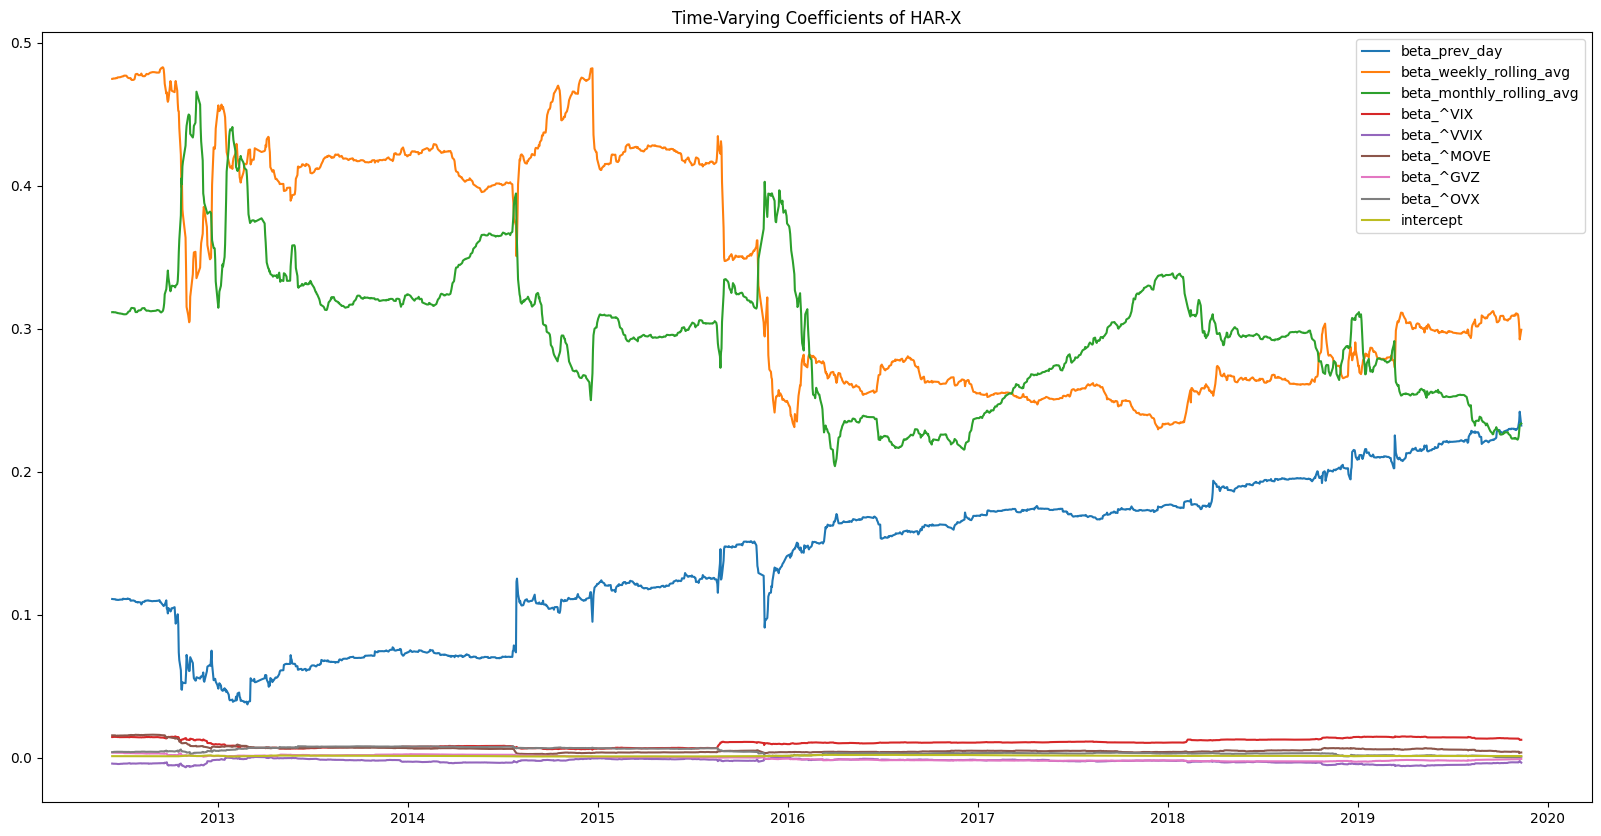

In [41]:
coeffs = scaled_harx_backtest.iloc[:, :-2]
fig = plot_coeffs(coeffs, 'Time-Varying Coefficients of HAR-X')
plt.show()

Based on the chart, we see that VIX has increasing importance over time. On the other hand, VVIX reflects market-implied uncertainty about future volatility (vol-of-vol). While theoretically this could contain forward-looking information about volatility risk, its empirical contribution appears unstable once VIX itself is included.

Notably, OVX and GVZ also do not seem to contribute much to the forecasting of volatility. Meanwhile, MOVE has had decreasing importance over time likely due to change in regime with consistently low and stable interest rates.

We should explore the correlation between variables and perhaps employ PCA to mitigate that issue.

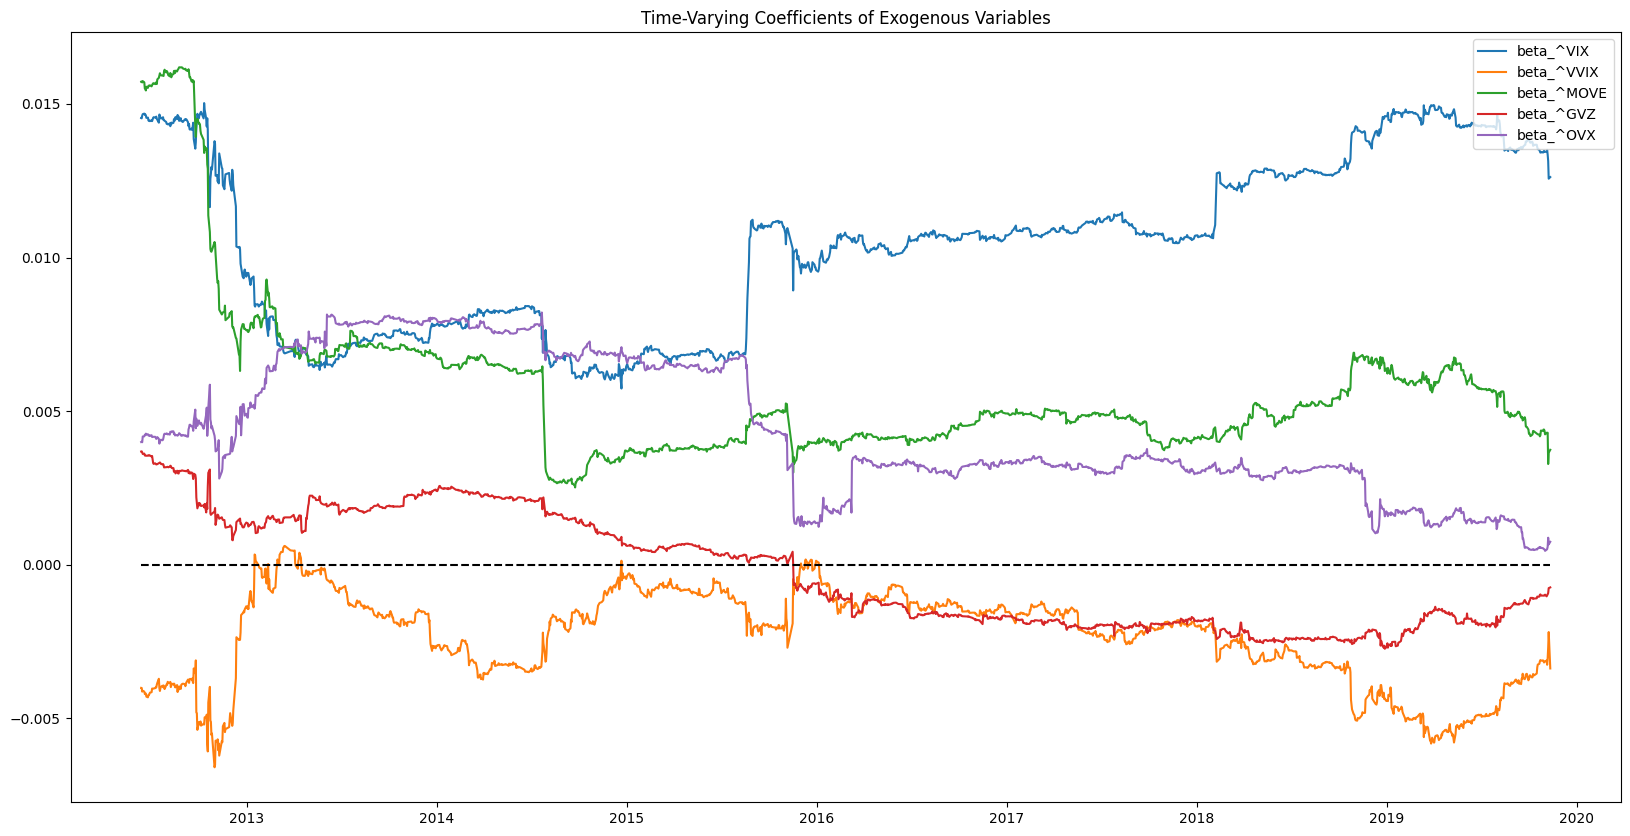

In [60]:
coeffs = scaled_harx_backtest.iloc[:, 3:-3]
fig = plot_coeffs(coeffs, 'Time-Varying Coefficients of Exogenous Variables')
plt.hlines(0, xmin=scaled_harx_backtest.index.min(), xmax=scaled_harx_backtest.index.max(), linestyles='--', colors='black')
plt.show()

## Correlation Analysis

Based on the Variance Inflation Factor (VIF), there does not seem to be any serious multicollinearity issues. We can ignore the high values for volatility-derived features as that is by design of HAR and a known characteristic of volatility.

In [109]:
predictors = scaled_harx.df.iloc[:, 1:]
vif = pd.Series(
    [variance_inflation_factor(predictors.values, i) for i in range(predictors.shape[1])],
    index=predictors.columns
)
print(vif)

prev_day                8.356652
weekly_rolling_avg     20.731690
monthly_rolling_avg    13.817708
^VIX                    3.545197
^VVIX                   3.102769
^MOVE                   1.100900
^GVZ                    1.247629
^OVX                    1.263829
dtype: float64


Based on the correlation to VIX, we see that VVIX does have high correlation and that is to be expected. One way is to apply a PCA onto VIX and VVIX, however we should try an experiment by applying a PCA onto all the features. Ideally, PCA1 would correspond to global market factors, while PCA2 would correspond to rates vs risk asset factor.

In [91]:
filtered_scaled_exo_df = scaled_exo_df.loc[scaled_exo_df.index < train_end_date].dropna()
vix_series = filtered_scaled_exo_df['^VIX']
rolling_corr = (
    filtered_scaled_exo_df
    .drop(columns=['^VIX'])
    .rolling(window=1000)
    .corr(vix_series)
    .dropna()
)
rolling_corr.head(5)

,^VVIX,^MOVE,^GVZ,^OVX
date,,,,
2012-06-11,0.736464,0.241273,0.404205,0.491876
2012-06-12,0.736482,0.240711,0.403616,0.492660
2012-06-13,0.737196,0.241623,0.404688,0.493010
2012-06-14,0.735187,0.238415,0.404343,0.487420
2012-06-15,0.735604,0.238840,0.404727,0.488211


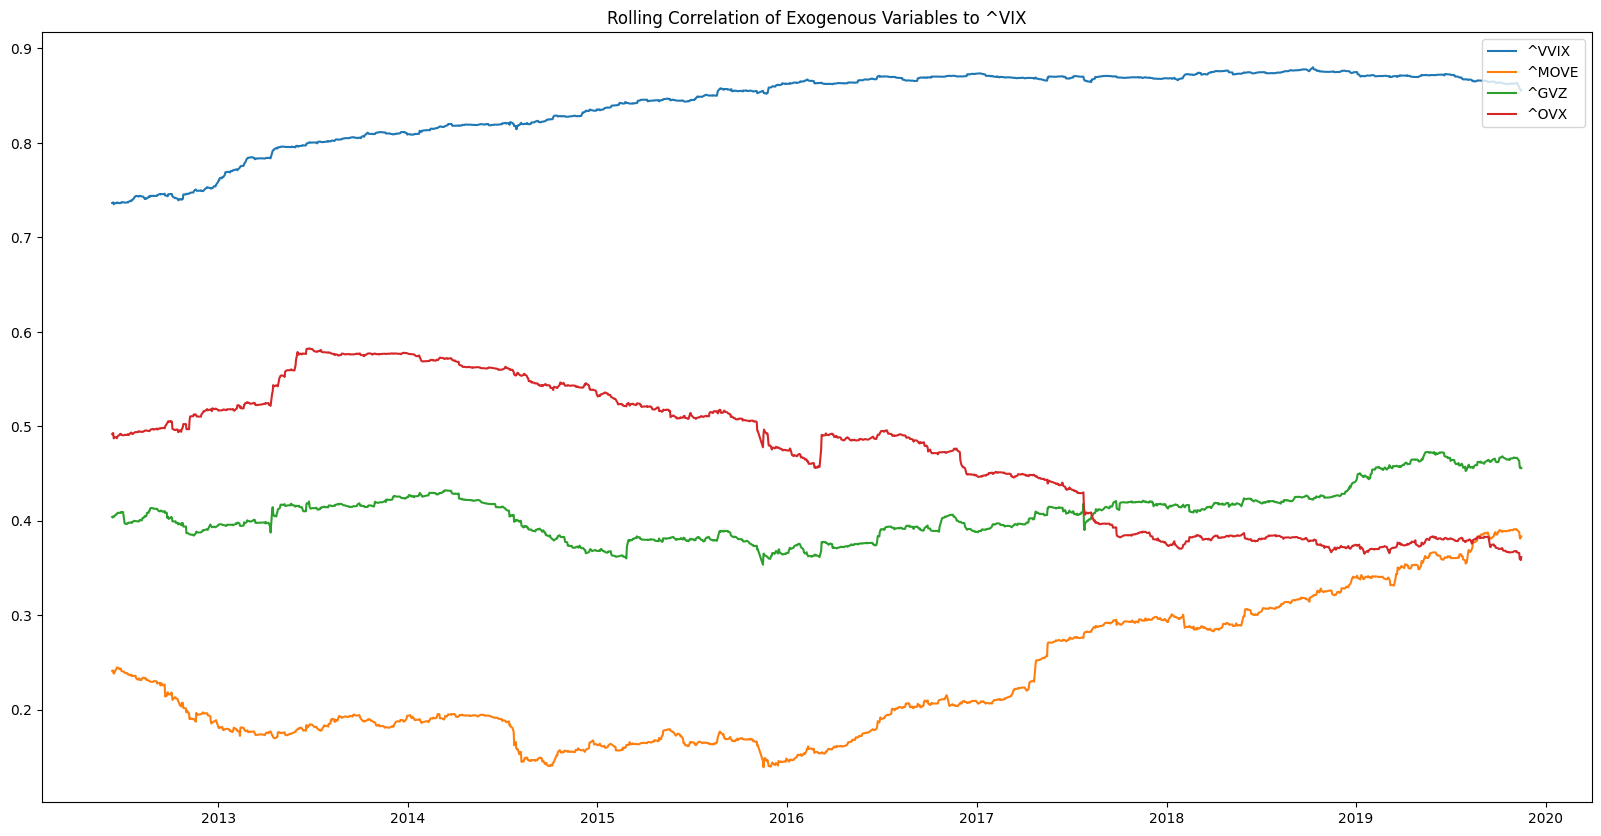

In [92]:
fig = plot_coeffs(rolling_corr, 'Rolling Correlation of Exogenous Variables to ^VIX')
plt.show()

## Principal Component Analysis (PCA)
Principal Component Analysis (PCA) is a dimensionality reduction technique. It identifies the directions with the highest variance and project the data along the components to reduce the dimensionality. This means that each component must be a unit vector (magnitude of 1).

Given a data matrix, we seek to maximize the following function:
$$\max_{w} \ w^{T} \Sigma w$$
where $\Sigma = \frac{1}{n-1}X^TX$ is the covariance matrix, under the constraint that $||{w}|| = w^Tw=1$.

This gives us the Lagrange function:
$$L(w,\lambda) = w^T\Sigma w -\lambda(w^Tw-1)$$
$$\Sigma w - \lambda w = 0$$
$$\Sigma w = \lambda w$$

Note that this is equivalent to a typical eigenvalue problem:
$$(\Sigma - \lambda I)W = 0$$

After solving for the eigenvalues and eigenvectors, we will have the following:
- $\Sigma$ is our covariance matrix.
- $\lambda$ is our eigenvalues or the variance explained by each principal component.
- $W$ is the matrix of eigenvectors or the direction of principal components.

PCA assumes data is z-score standardized: each feature has zero mean and unit variance. Let us denote the scaled dataset as $X$.

After obtaining the eigenvalues and eigenvectors, we sort the eigenvectors in descending order of their corresponding eigenvalues. The eigenvector with the highest eigenvalue is the first principal component. Then, we select the number of dimensions $k$.

Finally, we transform the dataset by projecting it onto the principal components. Given the matrix of selected eigenvectors $W$, we compute the transformed dataset $Y$ as:
$$Y = XW$$

In PCA, a loading is the weight or coefficient that links an original variable to a principal component. It tells you how strongly a feature contributes to a given component.

If we have $p$ features, we would have $p$ eigenvectors with $p$ elements. Naturally, this means each PC is denoted by:
$$PC_k = w^T_kX$$
$$PC_k = w_{k1}X_1 + ... + w_{kp}X_p$$
where $w$ is the corresponding eigenvector or the loading.

In [206]:
window = 1000
X = filtered_scaled_exo_df.dropna().copy()

loading_series1 = np.zeros(shape=(len(X)-window+1,X.shape[1]))
loading_series2 = loading_series1.copy()
loading_series3 = loading_series1.copy()
variance_explained = np.zeros(shape=(len(X)-window+1, 3))

for t in range(window, len(X)+1):
    X_window = X.iloc[t-window:t]
    X_scaled = StandardScaler().fit_transform(X_window)
    
    pca = PCA(n_components=3)
    principal_components = pca.fit_transform(X_scaled)
    eigenvectors = pca.components_
    var = pca.explained_variance_ratio_
    
    idx = t-window
    loading_series1[idx] = eigenvectors[0]
    loading_series2[idx] = eigenvectors[1]
    loading_series3[idx] = eigenvectors[2]
    variance_explained[idx] = var

In order to intepret the charts better, we will use the latest date of the rolling window to represent each timestep.

In [208]:
idx = X.index[window-1:]
pc1_loads_df = pd.DataFrame(loading_series1, columns=X.columns, index=idx)
pc2_loads_df = pd.DataFrame(loading_series2, columns=X.columns, index=idx)
pc3_loads_df = pd.DataFrame(loading_series3, columns=X.columns, index=idx)
var_df = pd.DataFrame(variance_explained, columns=['PC1', 'PC2', 'PC3'], index=idx)

Based on the explained variance, we note that perhaps three components would be better. PC1 + PC2 could explain approximately 65% of the variance. However, if we include PC3, we can explain approximately 80% of the variance. This enables us to capture the dominant structure while discarding minor noise.

In [209]:
var_df['PC1+PC2'] = var_df['PC1'] + var_df['PC2']
var_df['Total'] = var_df['PC1+PC2'] + var_df['PC3']
var_df.head(5)

,PC1,PC2,PC3,PC1+PC2,Total
date,,,,,
2012-06-11,0.483513,0.184791,0.151362,0.668304,0.819667
2012-06-12,0.483427,0.184921,0.151504,0.668349,0.819853
2012-06-13,0.483710,0.184904,0.151379,0.668614,0.819992
2012-06-14,0.481806,0.185489,0.151208,0.667295,0.818503
2012-06-15,0.482474,0.184944,0.151236,0.667418,0.818654


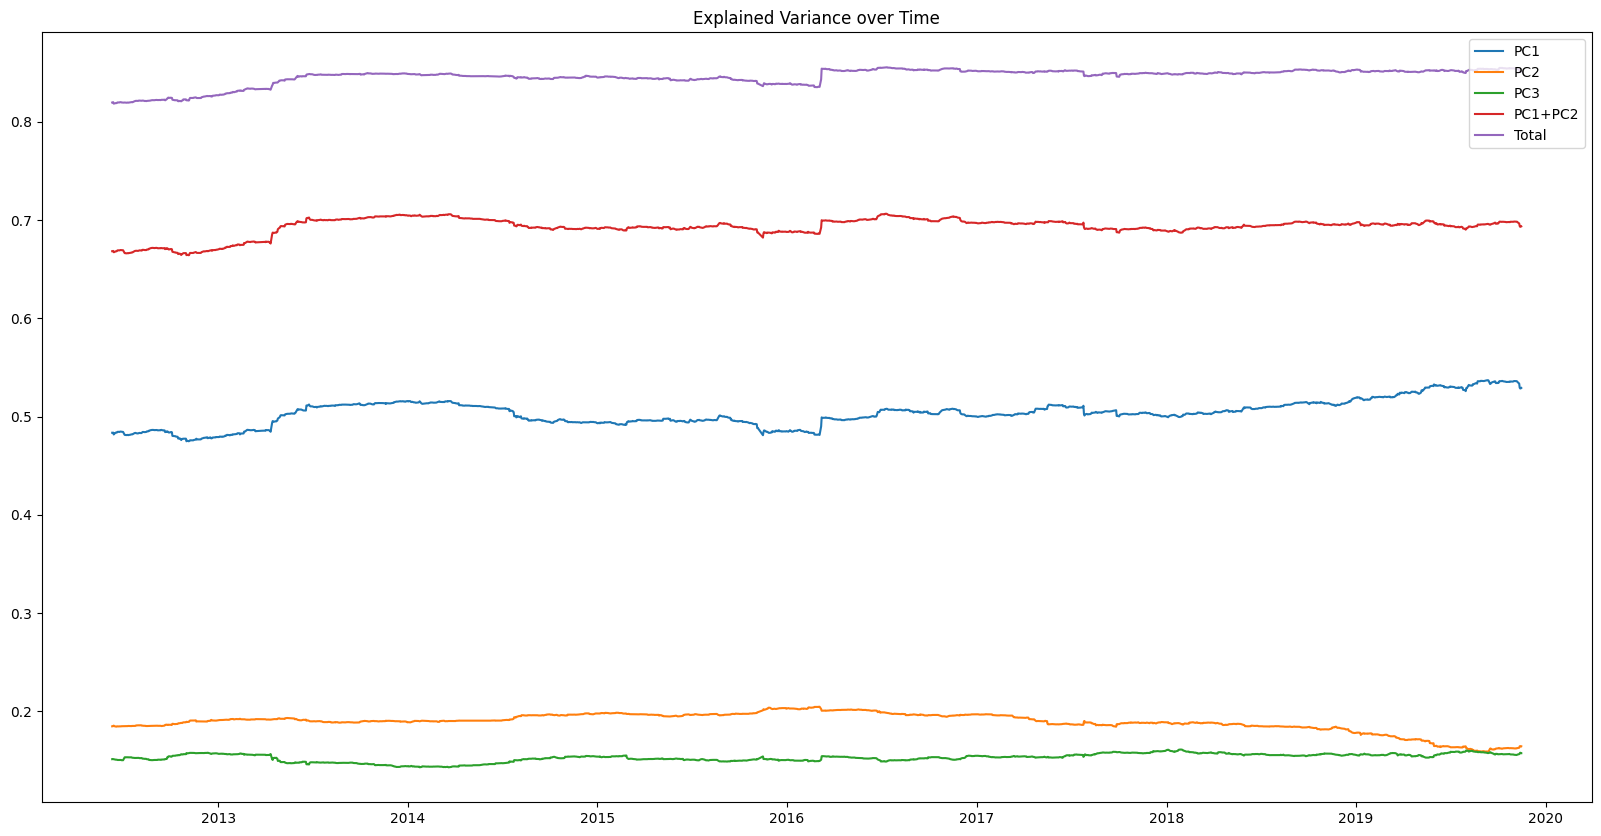

In [210]:
fig = plot_coeffs(var_df, 'Explained Variance over Time')
plt.show()

Based on the PC Loading, we note the following:
- PC1: Perhaps we should separate the PC for VIX and VVIX from the PC for MOVE, GVZ and OVX.
- PC2: This is dominated by MOVE, however we should first observe the impact of the aforementioned separation.
- PC3: Mainly commodities related movement, with notable impact from MOVE.

The period in 2019 seems to be quite volatile with the loadings of PC2 and PC3 spiking. This could be attributed to the Sep 2019 repo market event that triggered an emergency liquidity injection and also the ongoing US-China Trade War. Overall, it would be best to do a PCA for VIX and VVIX, and another from GVZ and OVX.

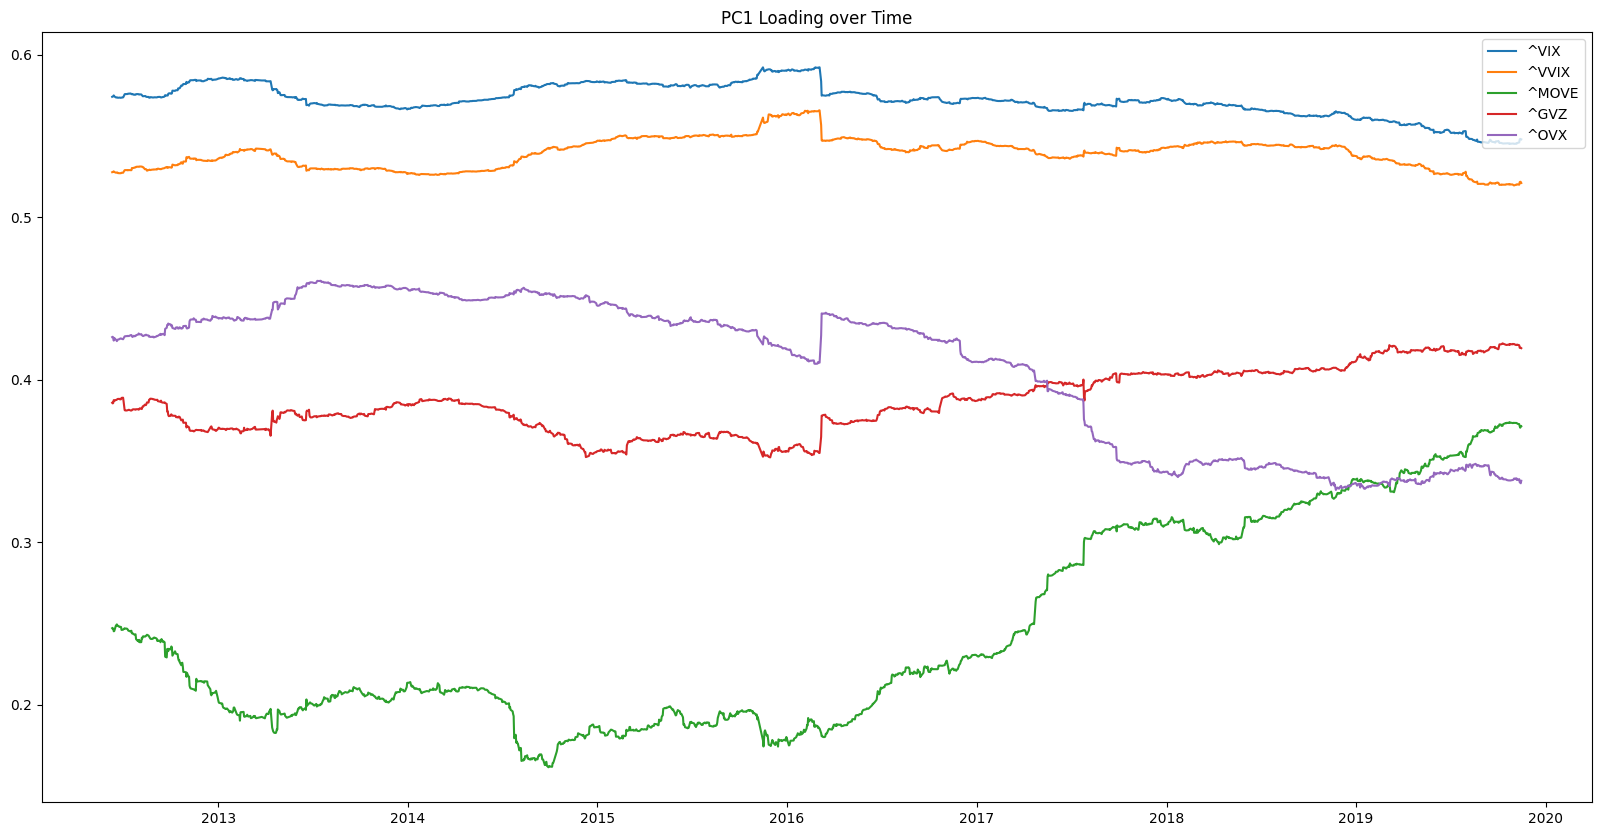

In [211]:
fig = plot_coeffs(pc1_loads_df, 'PC1 Loading over Time')
plt.show()

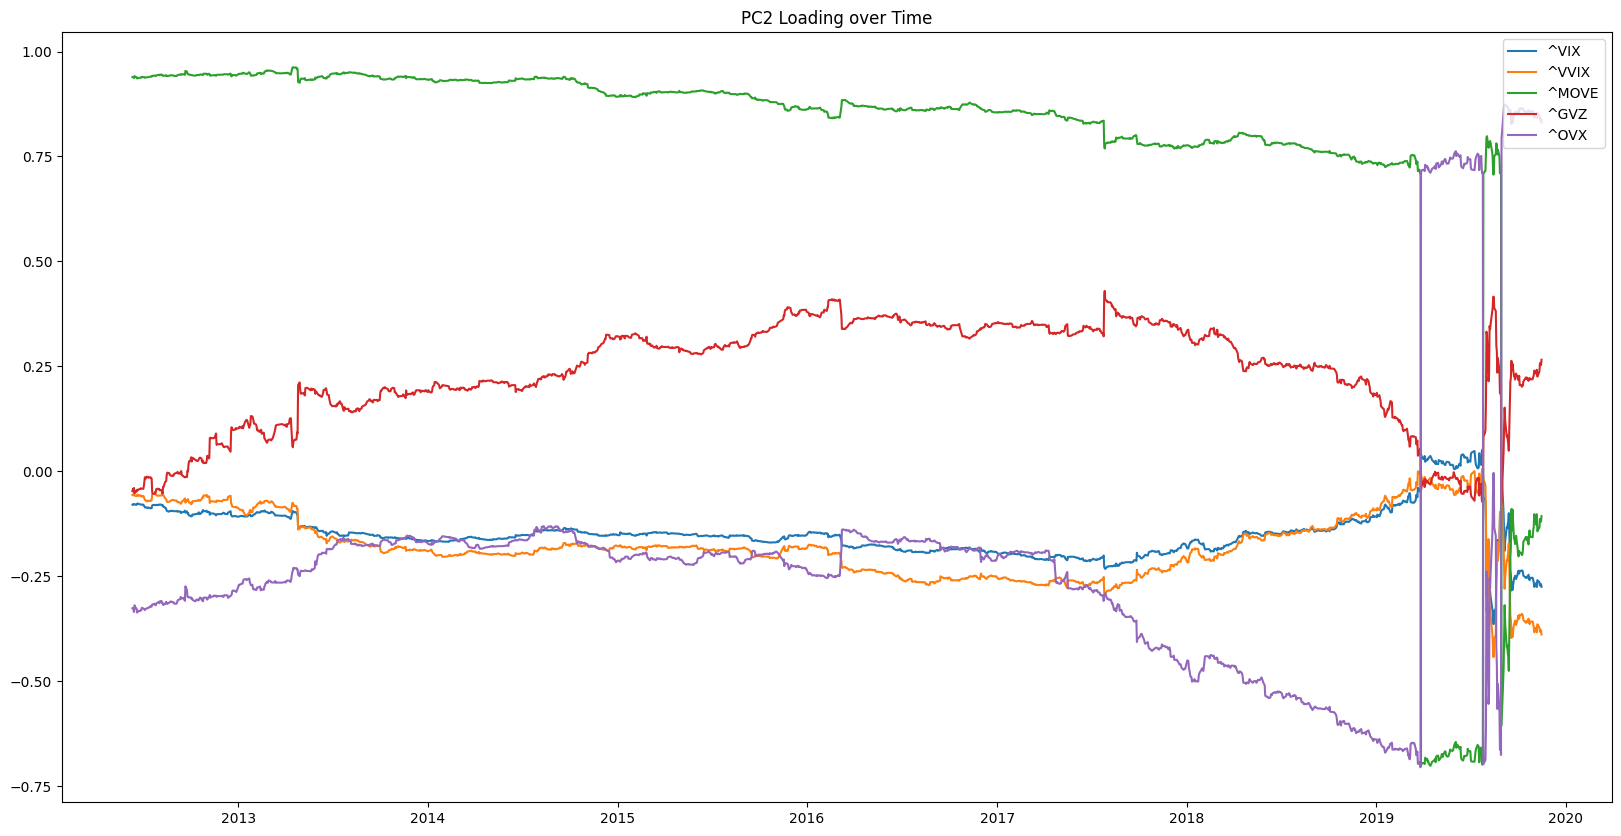

In [212]:
fig = plot_coeffs(pc2_loads_df, 'PC2 Loading over Time')
plt.show()

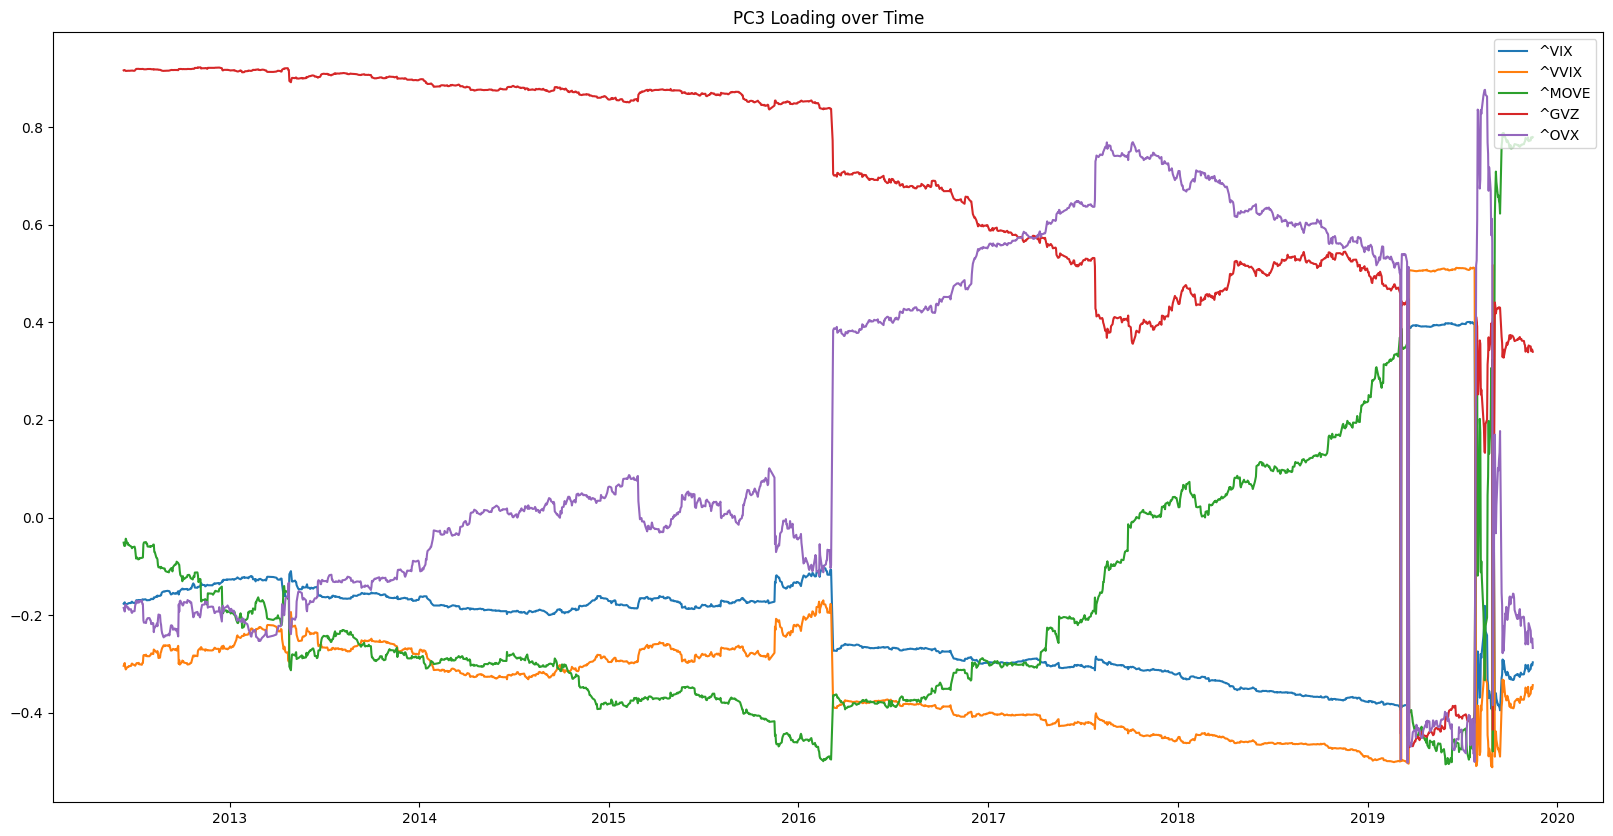

In [213]:
fig = plot_coeffs(pc3_loads_df, 'PC3 Loading over Time')
plt.show()

## VIX-Related PCA

In [225]:
window = 1000
vix = X.loc[:, ['^VIX', '^VVIX']]

loading_series1 = np.zeros(shape=(len(vix)-window+1,vix.shape[1]))
loading_series2 = loading_series1.copy()
variance_explained = np.zeros(shape=(len(vix)-window+1, 2))

for t in range(window, len(vix)+1):
    X_window = vix.iloc[t-window:t]
    X_scaled = StandardScaler().fit_transform(X_window)
    
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(X_scaled)
    eigenvectors = pca.components_
    var = pca.explained_variance_ratio_
    
    idx = t-window
    loading_series1[idx] = eigenvectors[0]
    loading_series2[idx] = eigenvectors[1]
    variance_explained[idx] = var

idx = vix.index[window-1:]
pc1_loads_df = pd.DataFrame(loading_series1, columns=vix.columns, index=idx)
pc2_loads_df = pd.DataFrame(loading_series2, columns=vix.columns, index=idx)
var_df = pd.DataFrame(variance_explained, columns=['PC1', 'PC2'], index=idx)
var_df['Total'] = var_df['PC1'] + var_df['PC2']

Since PC1 explains most of the variance, we can exclude the noise component PC2.

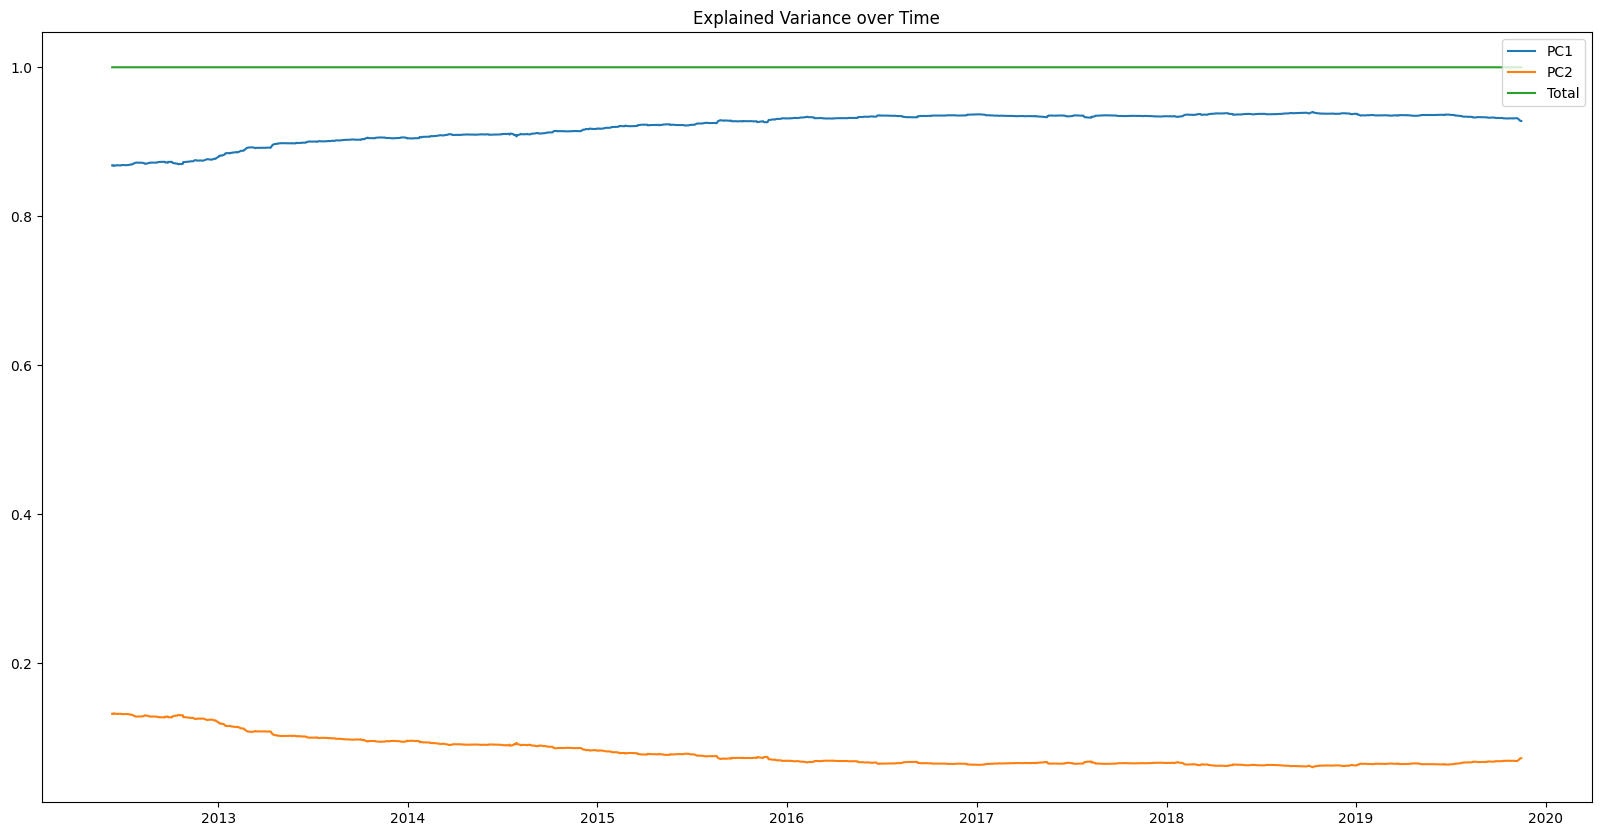

In [226]:
fig = plot_coeffs(var_df, 'Explained Variance over Time')
plt.show()

## Commodities-Related PCA

In [238]:
window = 1000
commodities = X.loc[:, ['^MOVE', '^GVZ', '^OVX']]

loading_series1 = np.zeros(shape=(len(commodities)-window+1,commodities.shape[1]))
loading_series2 = loading_series1.copy()
loading_series3 = loading_series1.copy()
variance_explained = np.zeros(shape=(len(commodities)-window+1, 3))

for t in range(window, len(commodities)+1):
    X_window = commodities.iloc[t-window:t]
    X_scaled = StandardScaler().fit_transform(X_window)
    
    pca = PCA(n_components=3)
    principal_components = pca.fit_transform(X_scaled)
    eigenvectors = pca.components_
    var = pca.explained_variance_ratio_
    
    idx = t-window
    loading_series1[idx] = eigenvectors[0]
    loading_series2[idx] = eigenvectors[1]
    loading_series3[idx] = eigenvectors[2]
    variance_explained[idx] = var

idx = commodities.index[window-1:]
pc1_loads_df = pd.DataFrame(loading_series1, columns=commodities.columns, index=idx)
pc2_loads_df = pd.DataFrame(loading_series2, columns=commodities.columns, index=idx)
pc3_loads_df = pd.DataFrame(loading_series3, columns=commodities.columns, index=idx)
var_df = pd.DataFrame(variance_explained, columns=['PC1', 'PC2', 'PC3'], index=idx)
var_df['Total'] = var_df['PC1'] + var_df['PC2'] + var_df['PC3']

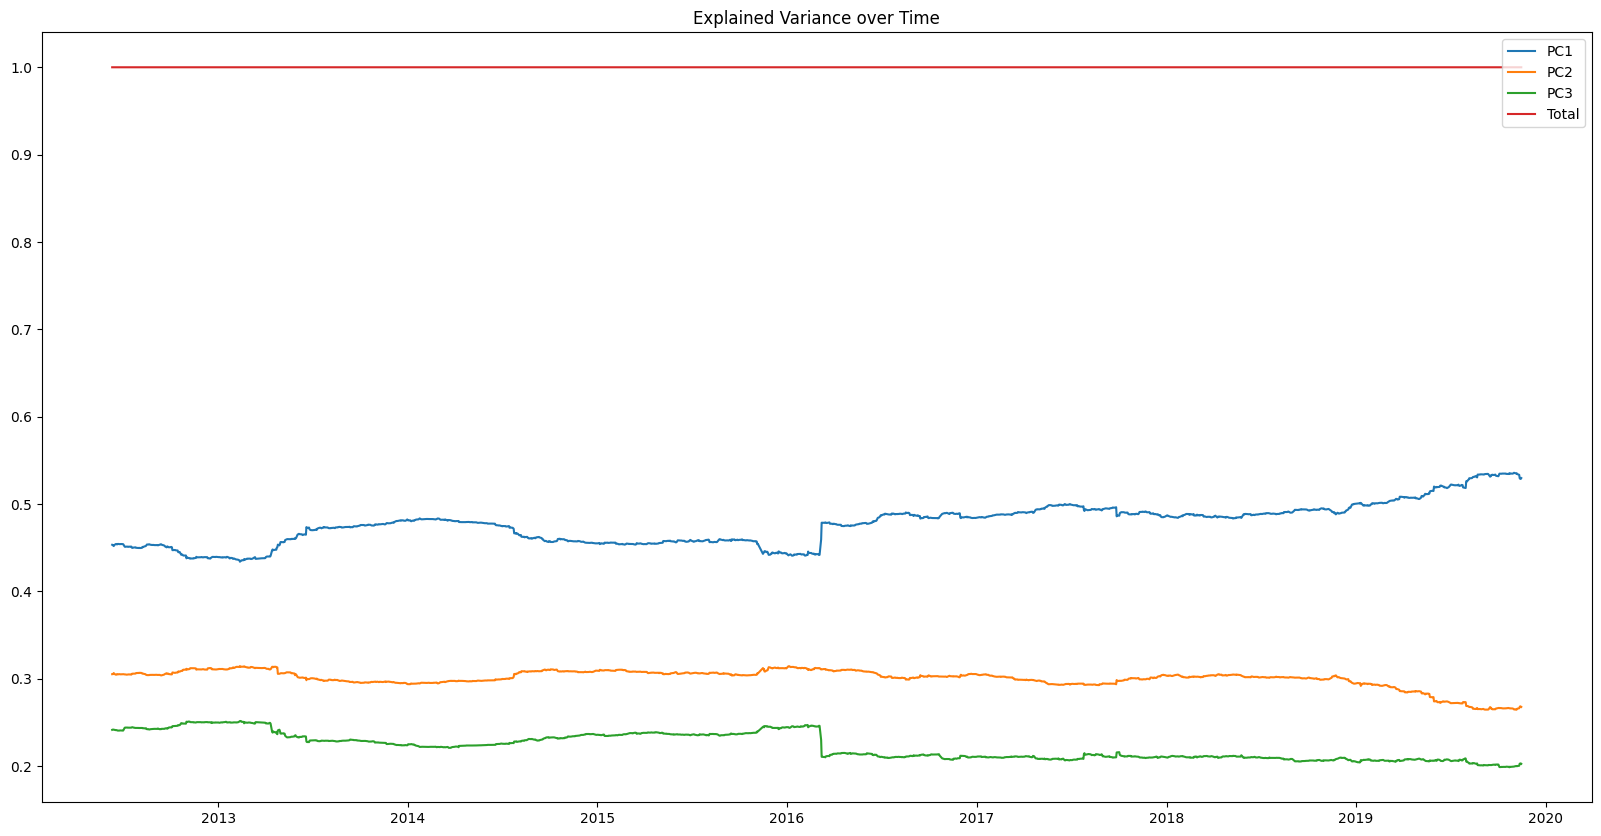

In [239]:
fig = plot_coeffs(var_df, 'Explained Variance over Time')
plt.show()

For PC1, we see that GVZ's loading is quite stable over time. Meanwhile, MOVE and OVX tend to move in opposite directions and have eventually swapped levels in the middle of 2017. Overall, PC1 seems to capture the cross-asset volatility factor or a latent macro uncertainty factor.

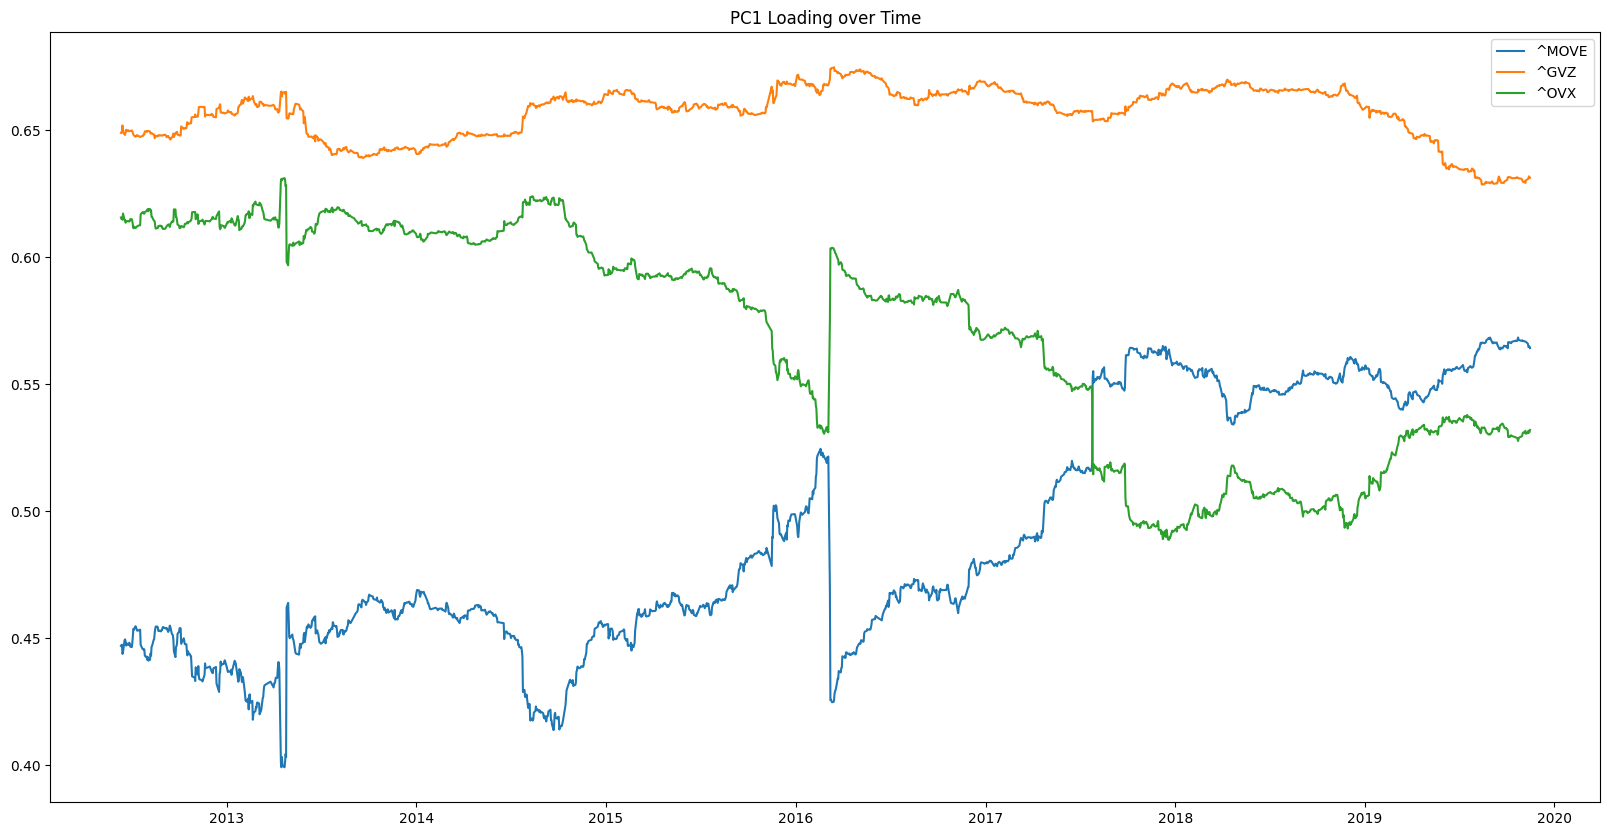

In [240]:
fig = plot_coeffs(pc1_loads_df, 'PC1 Loading over Time')
plt.show()

For PC2, we note that the coefficients can have opposing signs. This indicates that PC2 measures relative dominance or essentially which asset is the main contributor of volatility. Meanwhile for PC3, it seems to have a similar pattern to PC1 and hence we shall exclude it.

Regarding PC2, though encdoing information about relative dominance could be useful, it is a second-order information that would likely provide marginal improvement. In short, we believe that realized volatility is mostly driven by the level of uncertainty, "How volatile is the world?" matters more than "Which market is more volatile?".

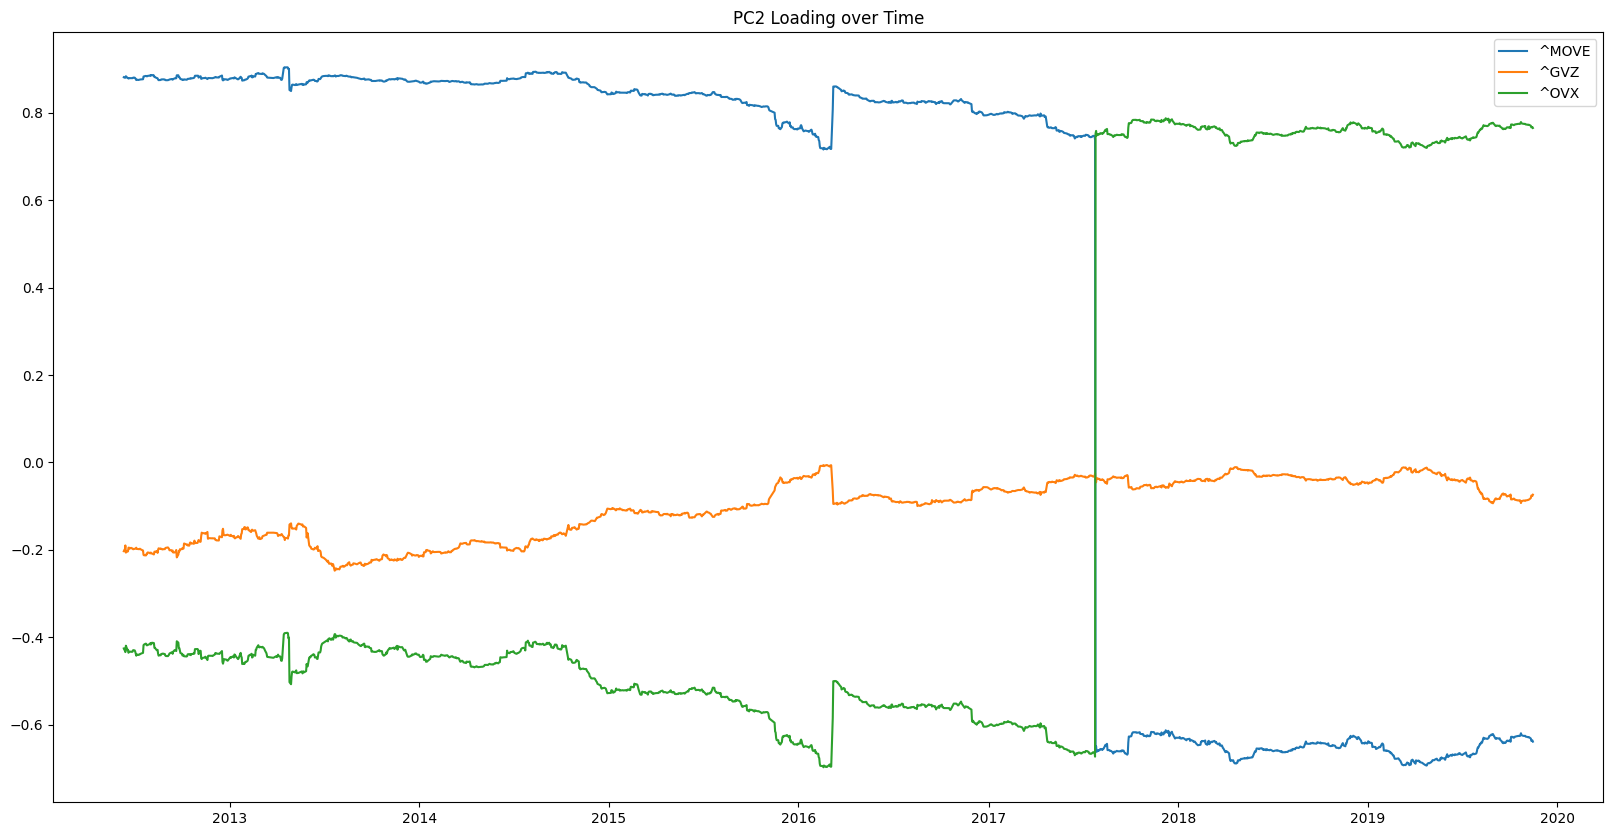

In [241]:
fig = plot_coeffs(pc2_loads_df, 'PC2 Loading over Time')
plt.show()

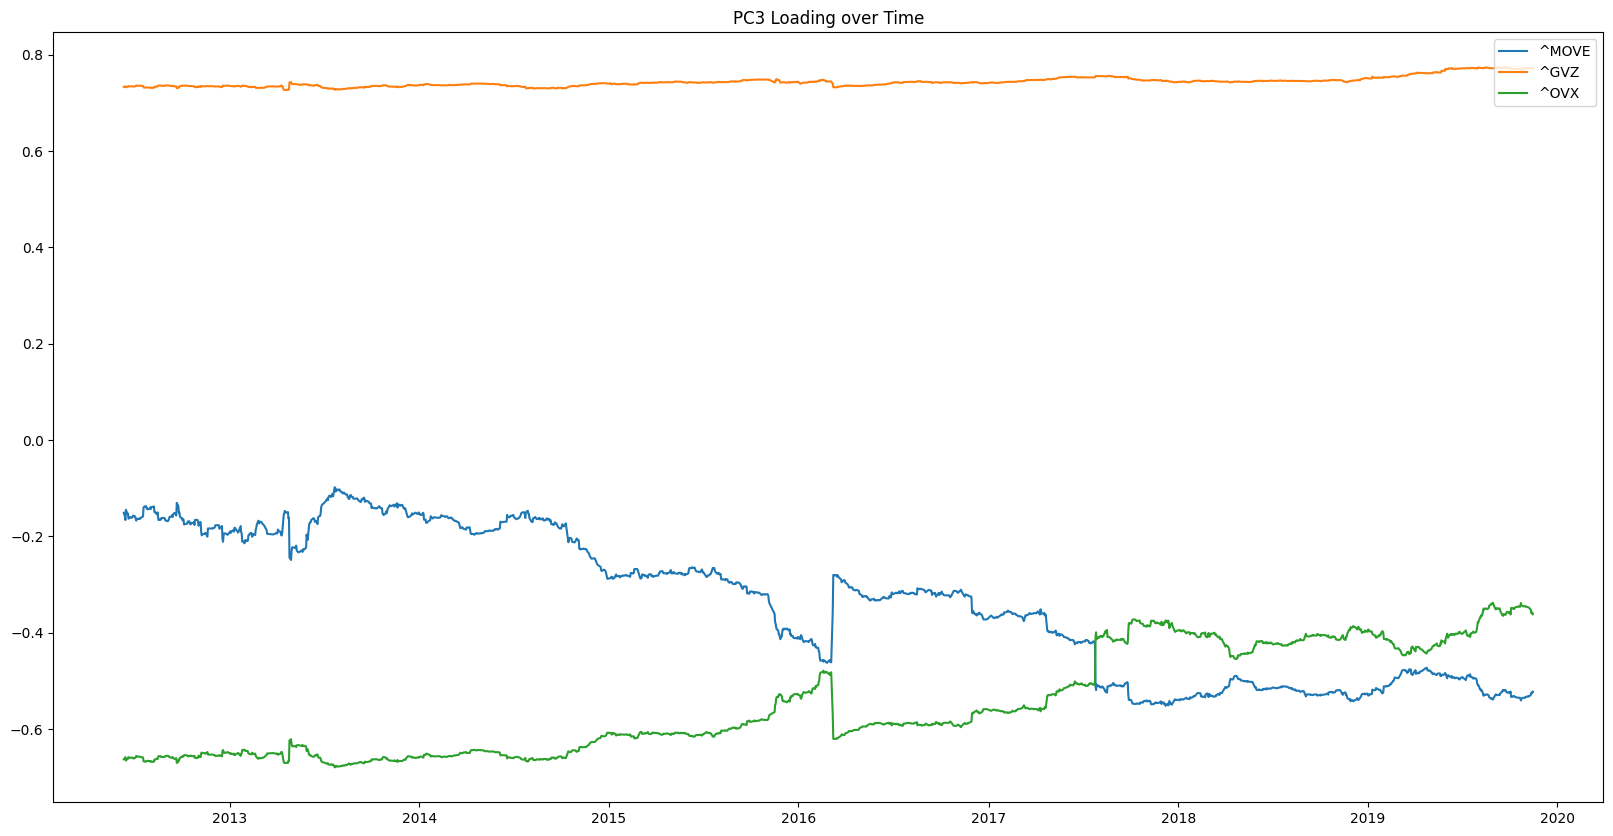

In [242]:
fig = plot_coeffs(pc3_loads_df, 'PC3 Loading over Time')
plt.show()

# HAR-X with PCA Features

# Comparison to High-Frequency Realized Volatility
For our target variable, we will calculate the realized volatility using a high-frequency estimator as denoted in the paper by:

$RV_t = \sqrt{\sum^M_{i=1}r^2_{t, i}}$

where $r_{t,i}$ represents the $i$-th intraday return on trading day $t$.

## Alpaca Client

In order to get the intraday data, we will be using Alpaca Markets. Refer to the following documentation: https://docs.alpaca.markets/reference/stockbars

Consequently, we need to create a free account and generate the API Key and Secret Key to access the data. A "secrets.env" file must be created in the parent folder, with the following values:
- ALPACA_KEY=API_KEY
- ALPACA_SECRET=SECRET_KEY

Note that the earliest available data starts from 2016, so we are unable to replicate the paper faithfully.

In [ ]:
from dotenv import load_dotenv
load_dotenv("secrets.env")
ALPACA_KEY = os.getenv("ALPACA_KEY")
ALPACA_SECRET = os.getenv("ALPACA_SECRET")

In [ ]:
alpaca_client = AlpacaStockData(api_key=ALPACA_KEY, secret_key=ALPACA_SECRET)
intraday_df = alpaca_client.get_stock_bar(symbol=symbol, start=start_date, end=end_date)
intraday_df.index = intraday_df.index.droplevel(0)
intraday_df.head(5)

,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2016-01-01 00:00:00+00:00,204.05,204.08,204.05,204.08,500.0,6.0,204.057500
2016-01-01 00:05:00+00:00,204.01,204.05,204.01,204.05,750.0,3.0,204.024430
2016-01-01 00:10:00+00:00,204.09,204.09,204.01,204.01,350.0,2.0,204.032857
2016-01-01 00:45:00+00:00,204.04,204.04,204.04,204.04,300.0,2.0,204.040000
2016-01-01 00:50:00+00:00,204.02,204.07,204.02,204.07,650.0,3.0,204.031538


In [ ]:
def intraday_rv(intraday_df:pd.DataFrame, date_format:str='%d/%m/%Y') -> pd.Series:
    df = intraday_df.copy()
    df['log_returns'] = np.log(df['close']).diff()
    rv = (
        df['log_returns'].dropna()
        .pow(2)
        .resample("1D")
        .sum()
    )
    rv.name = 'realized_volatility'
    rv.index = pd.to_datetime(rv.index, format=date_format).tz_localize(None).normalize() #Standardize date format to be tz-naive
    return np.sqrt(rv)

target_rv = intraday_rv(intraday_df)

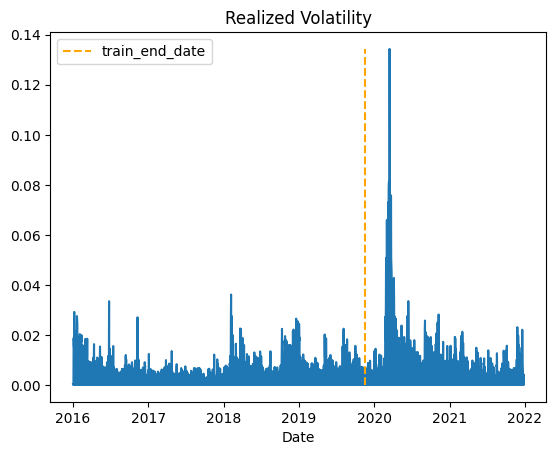

In [ ]:
plt.plot(target_rv)
plt.vlines(train_end_date, ymin=0, ymax=target_rv.max(), linestyles='--', color='orange', label='train_end_date')
plt.title("Realized Volatility")
plt.xlabel("Date")
plt.legend(loc=2)
plt.show()

In [ ]:
actual_rv_train = target_rv.loc[target_rv.index < train_end_date]
actual_rv_train

timestamp
2016-01-01    0.000321
2016-01-02    0.000000
2016-01-03    0.000000
2016-01-04    0.018735
2016-01-05    0.015130
                ...   
2019-11-12    0.004259
2019-11-13    0.004990
2019-11-14    0.004307
2019-11-15    0.003926
2019-11-16    0.000000
Freq: D, Name: realized_volatility, Length: 1416, dtype: float64

## Performance Measures
Quasi-Likelihood (QLIKE) is a way to do likelihood-based estimation and inference without fully specifying the true data distribution. This is useful as the true distribution for volatility is unknown, and if we were to infer the distribution, it would typically be time-varying, non-Gaussian, and with heavy-tails. The classical notation is denoted as:
$$QLIKE = \frac{RV_t}{F_t} + logF_t + c$$

From the equation, we can observe that the loss function penalizes under-forecast more than over-forecast. It also ensures that one cannot cheat by forecasting an absurdly high value through the $logF_t$ term. Overall, this is perfect for volatility where we are typically more concerned with missing volatility spikes.

Note that the $logF_t$ can be rewritten in the following form:
$$logF_t = logRV_t - log\frac{RV_t}{F_t}$$

Since $logRV_t$ will be a constant between models, it does not affect our model comparison and hence can be dropped. After substitution, we get the following:
$$QLIKE = \frac{RV_t}{F_t} - log\frac{RV_{t}}{F_t} + c$$

Lastly, if $RV_t = F_t$ we will have $1-0+c = 1+c$, and therefore, for convenience we can set $c = -1$:
$$QLIKE = \frac{RV_t}{F_t} - log\frac{RV_{t}}{F_t} - 1$$

Staying true to the paper, we will use the Mean Squared Error (MSE) and QLIKE to assess out-of-sample forecast accuracy. These are defined as:
$$MSE=\frac{1}{T}\sum^T_{t=1}\left(RV_{t+h-1|t} - F_t\right)^2$$
$$QLIKE = \frac{1}{T}\sum^T_{t=1}\left(\frac{RV_{t+h-1|t}}{F_t} - log\frac{RV_{t+h-1|t}}{F_t}-1\right)$$
$$RV_{t+h-1|t} = \frac{1}{h}\sum^{t+h-1}_{i=t}RV_i, \quad h \geq 1$$
where $T$ is the number of forecasts and $F_t$ is the forecast.

In [ ]:
def mean_squared_error(actual:pd.Series, forecast:pd.Series) -> float:
    squared_error = (actual - forecast)**2
    return np.mean(squared_error)

def qlike(actual_variance:pd.Series, forecast_variance:pd.Series) -> float:
    diff = actual_variance/forecast_variance
    error = (diff - np.log(diff) - 1)
    return np.mean(error)

## Training Set

In [ ]:
def get_actual_forecast(eval_df:pd.DataFrame) -> tuple:
    actual = eval_df.iloc[:, 1]
    forecast = eval_df.iloc[:, 0]
    return actual, forecast

def print_metrics(actual, forecast):
    garch_mse = mean_squared_error(actual, forecast)
    garch_qlike = qlike(actual, forecast)
    print(f"MSE: {garch_mse}\nQLIKE: {garch_qlike}")

def plot_comparison(actual, forecast, title) -> plt.Figure:
    plt.plot(forecast, color='red', label='predicted')
    plt.plot(actual, color='black', alpha=0.5, label='target')
    plt.title(title) 
    plt.ylabel("Volatility")
    plt.xlabel("Dates")
    fig = plt.gcf()
    fig.set_size_inches(20,5)
    plt.legend()
    return fig

MSE: 1.1212494024905262e-05
QLIKE: 0.06919887679084023


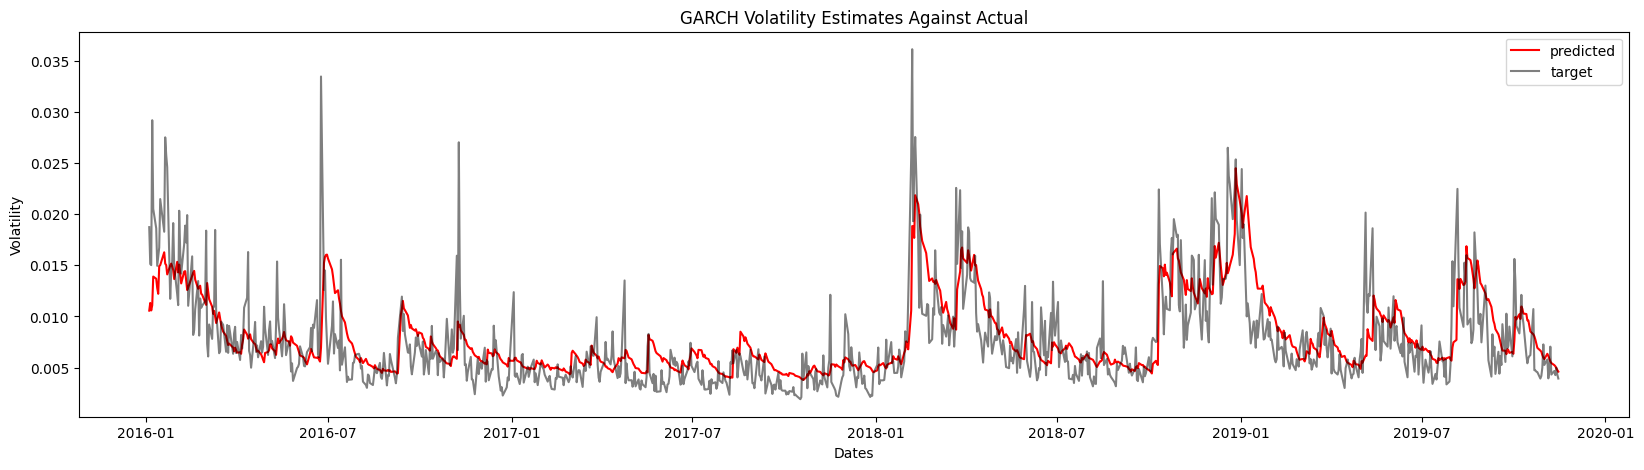

In [ ]:
garch_eval_df = pd.concat([garch_vol, actual_rv_train], axis=1, join='inner')
actual, forecast = get_actual_forecast(garch_eval_df)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "GARCH Volatility Estimates Against Actual")
plt.show()

MSE: 1.0855873565972248e-05
QLIKE: 0.06780374836979629


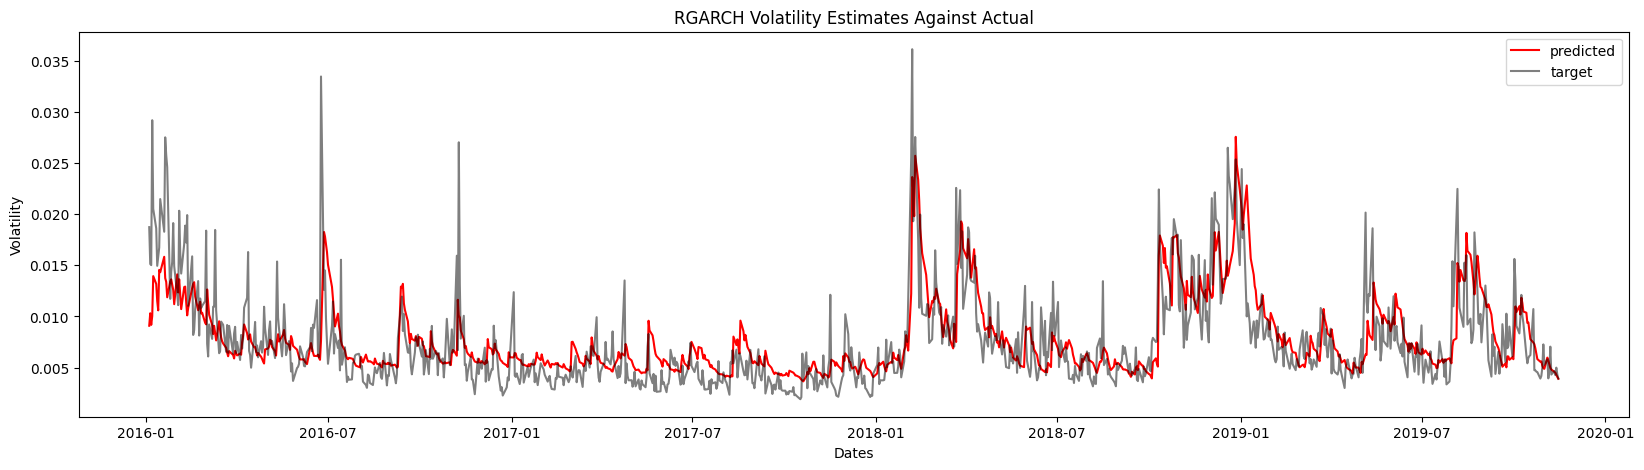

In [ ]:
r_garch_eval_df = pd.concat([r_garch_eval['preds'], actual_rv_train], axis=1, join='inner')
actual, forecast = get_actual_forecast(r_garch_eval_df)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "RGARCH Volatility Estimates Against Actual")
plt.show()

MSE: 1.4268106740353928e-05
QLIKE: 0.10242415857414044


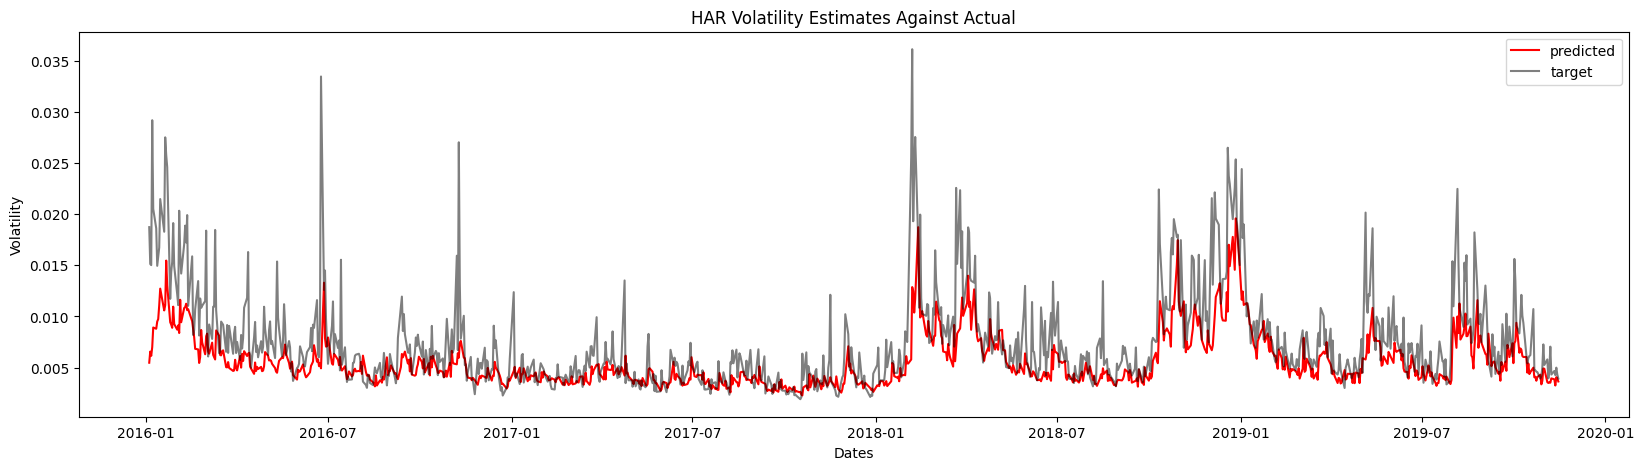

In [ ]:
d_eval = d_har.backtest(horizon=1)
d_eval_df = pd.concat([d_eval['y_hat'], actual_rv_train], axis=1, join='inner')

actual, forecast = get_actual_forecast(d_eval_df)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "HAR Volatility Estimates Against Actual")
plt.show()

MSE: 1.2024099088139629e-05
QLIKE: 0.11107549889349673


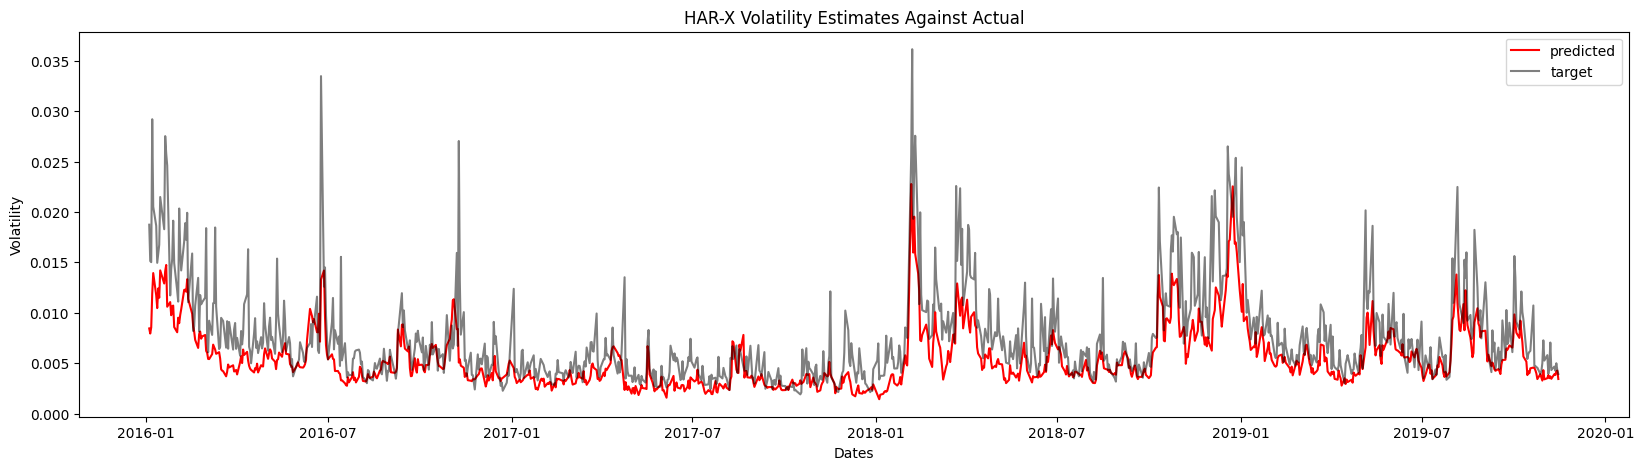

In [ ]:
dx_eval = d_harx.backtest(horizon=1)
dx_eval_df = pd.concat([dx_eval['y_hat'], actual_rv_train], axis=1, join='inner')

actual, forecast = get_actual_forecast(dx_eval_df)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "HAR-X Volatility Estimates Against Actual")
plt.show()

MSE: 1.1226654272880869e-05
QLIKE: 0.10291587156754575


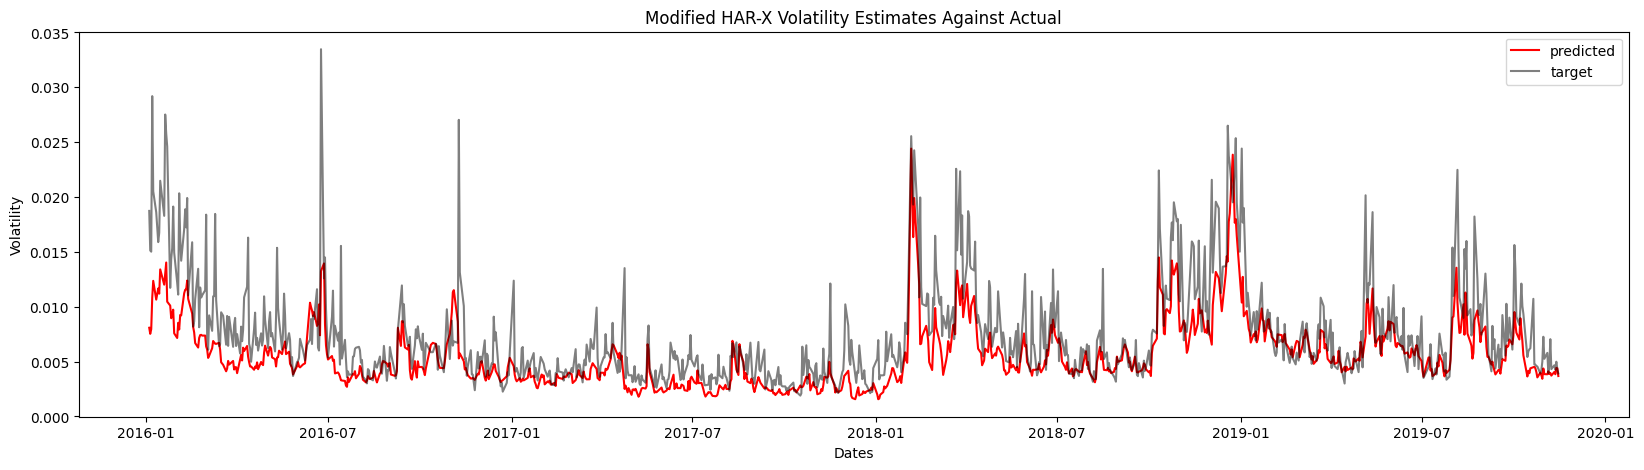

In [ ]:
modified_dx_eval = modified_d_harx.backtest(horizon=1)
modified_dx_eval_df = pd.concat([modified_dx_eval['y_hat'], actual_rv_train], axis=1, join='inner')

actual, forecast = get_actual_forecast(modified_dx_eval_df)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "Modified HAR-X Volatility Estimates Against Actual")
plt.show()

MSE: 1.2922167519118903e-05
QLIKE: 0.11625078270059853


c:\Users\Finn_Nitro\Documents\GitHub\Regime-Classification\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


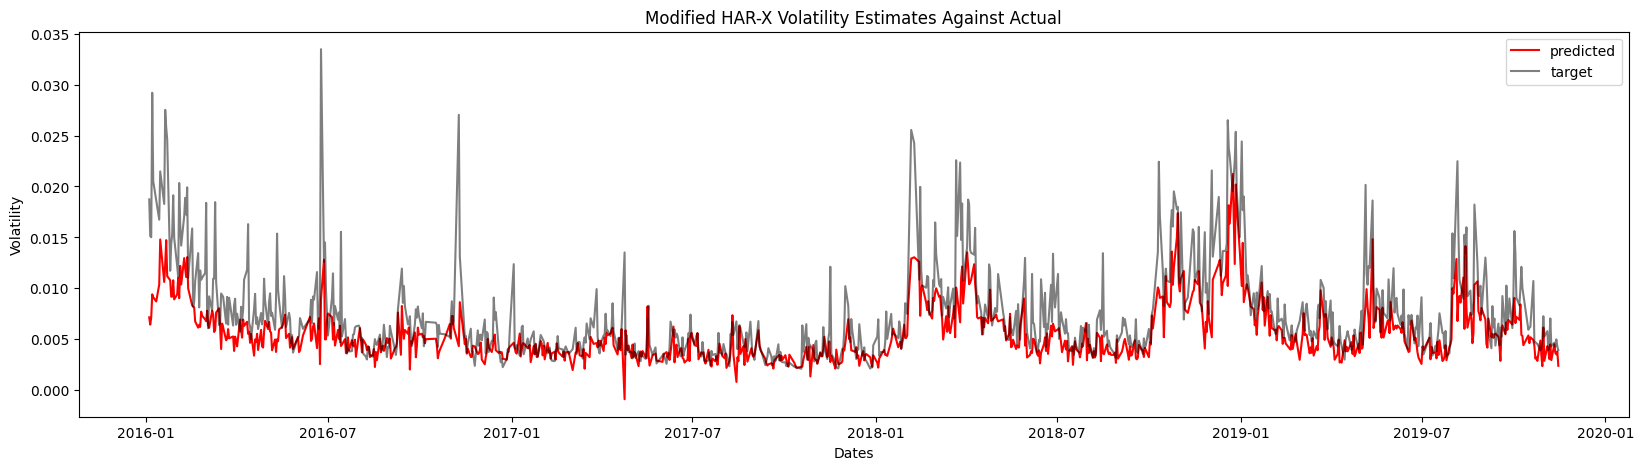

In [ ]:
modified_dx_eval_2 = modified_d_harx_2.backtest(horizon=1)
modified_dx_eval_df_2 = pd.concat([modified_dx_eval_2['y_hat'], actual_rv_train], axis=1, join='inner')

actual, forecast = get_actual_forecast(modified_dx_eval_df_2)
print_metrics(actual, forecast)
plot_comparison(actual, forecast, "Modified HAR-X Volatility Estimates Against Actual")
plt.show()

## Test Set